# DroneTask — internal design inspector

A static analyser for the experiment's JS source. It parses
`index.html`, `stimuli.js`, `stimuli-details.js`, and `memory_task.js`
and reconstructs:

- the per-block factor design (volatility, stochasticity, valence)
- the latent bird/bag trajectories and their inferred change points
- the memory-task pair structure
- the emoji → trial assignment scheme
- the consequences of `randomized` counter-balancing for recorded
  factor labels

All figures and tables are rendered inline at high resolution and
exported to `design_checks/` for inclusion in papers/posters.

> Run the notebook from the repo root (the directory containing
> `index.html` and `static/`). `REPO_ROOT` is auto-detected.


## Setup


### Imports, paths, and output directory

Auto-locates the repo root by walking up from the notebook's working
directory until it finds an `index.html` and `static/task/` pair. All
exported figures/tables land in `design_checks/`.


In [39]:
from pathlib import Path
import re
import json
import itertools
import html as html_lib
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML, display


def _find_repo_root(start: Path) -> Path:
    for ancestor in [start.resolve(), *start.resolve().parents]:
        if (ancestor / "index.html").is_file() and (ancestor / "static" / "task").is_dir():
            return ancestor
    return start.resolve()


REPO_ROOT = _find_repo_root(Path.cwd())
TASK_DIR  = REPO_ROOT / "static" / "task"
INDEX_HTML = REPO_ROOT / "index.html"
OUT_DIR   = Path("design_checks")
OUT_DIR.mkdir(exist_ok=True)

print(f"Repo root  : {REPO_ROOT}")
print(f"Task dir   : {TASK_DIR}")
print(f"Output dir : {OUT_DIR.resolve()}")


Repo root  : /Users/yizj/Desktop/InCogLab/DroneTask
Task dir   : /Users/yizj/Desktop/InCogLab/DroneTask/static/task
Output dir : /Users/yizj/Desktop/InCogLab/DroneTask/design_checks


### Publication styling

Sets matplotlib rcParams once for clean serif-y figures, removes the
top/right spines, and bumps inline DPI so figures look sharp in the
notebook. Saved PNGs use a higher DPI for print quality.

A small `style_table` helper applies a consistent pandas-Styler look
(monospaced numerics, header bar, zebra rows, ✓/✗ colouring).


In [40]:
INLINE_DPI = 130
EXPORT_DPI = 220

mpl.rcParams.update({
    "figure.dpi":            INLINE_DPI,
    "savefig.dpi":           EXPORT_DPI,
    "savefig.bbox":          "tight",
    "figure.constrained_layout.use": True,

    "font.family":           "DejaVu Sans",
    "font.size":             9.5,
    "axes.titlesize":        10.5,
    "axes.titleweight":      "semibold",
    "axes.labelsize":        9.5,
    "xtick.labelsize":       8.5,
    "ytick.labelsize":       8.5,
    "legend.fontsize":       8,
    "legend.frameon":        False,

    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             True,
    "axes.axisbelow":        True,
    "grid.color":            "#e6e6e6",
    "grid.linewidth":        0.6,
    "axes.edgecolor":        "#444",
    "axes.linewidth":        0.8,

    "lines.linewidth":       1.6,
    "lines.solid_capstyle":  "round",
})


_TABLE_CSS = [
    {"selector": "th",
     "props": [("background-color", "#f3f3f3"), ("color", "#222"),
               ("font-weight", "650"), ("border", "1px solid #d6d6d6"),
               ("padding", "5px 10px"), ("text-align", "left")]},
    {"selector": "td",
     "props": [("border", "1px solid #e1e1e1"),
               ("padding", "4px 10px"),
               ("font-variant-numeric", "tabular-nums")]},
    {"selector": "tr:nth-child(even) td",
     "props": [("background-color", "#fafafa")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"),
               ("font-size", "12px"),
               ("font-family", "-apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif")]},
    {"selector": "caption",
     "props": [("caption-side", "top"), ("padding", "4px 0"),
               ("color", "#444"), ("font-size", "12px"),
               ("text-align", "left"), ("font-weight", "600")]},
]


def style_table(df: pd.DataFrame, caption: str | None = None,
                pass_col: str | None = None):
    """Return a styled pandas DataFrame with the project's table look."""
    sty = df.style.set_table_styles(_TABLE_CSS).hide(axis="index")
    if caption:
        sty = sty.set_caption(caption)
    if pass_col is not None and pass_col in df.columns:
        def _color(v):
            if v == "✓": return "color: #1a7f37; font-weight: 700;"
            if v == "✗": return "color: #cf222e; font-weight: 700;"
            return ""
        # pandas >= 2.1 deprecated Styler.applymap in favour of Styler.map
        try:
            sty = sty.map(_color, subset=[pass_col])
        except AttributeError:
            sty = sty.applymap(_color, subset=[pass_col])
    return sty


def save_table_html(df: pd.DataFrame, name: str, caption: str | None = None,
                    pass_col: str | None = None) -> Path:
    out = OUT_DIR / f"{name}.html"
    out.write_text(style_table(df, caption=caption, pass_col=pass_col).to_html(),
                   encoding="utf-8")
    return out


### How randomization & counterbalancing works in the experiment

- **Latent bird/bag trajectories** are mostly fixed design sequences
  with a participant-level counterbalancing switch. `stimuli.js`
  defines four blocks (reward × {high, low} vol/stc; loss ×
  {high, low} vol/stc), provides base high-vol and low-vol bird/bag
  sequences, and creates shifted copies via `HIGHVOL_SHIFT_DELTA = 6`
  and `LOWVOL_SHIFT_DELTA = -4`. The boolean
  `reward_uses_shifted_sequences = Math.random() < 0.5` decides whether
  reward or loss blocks receive the shifted trajectories.

- **Emoji item identity** comes from a pool, not a fixed sequence. The
  pool is shuffled once per participant; trial *k* (zero-indexed
  globally) gets `pool[k % len(pool)]`. Different participants will
  generally see different emojis at any given block × trial.

- **Memory-test serial positions** are fixed across participants:
  `PREDEFINED_PAIRS` in `memory_task.js` is a fixed list of 1-based
  within-block trial indices.

- **Memory-test pair order** is randomised per block via
  `nextPairForBlock()`, which initialises
  `pairOrderByBlock[block] = jsPsych.randomization.shuffle(PREDEFINED_PAIRS.slice())`.
  Two participants can hit the same pair positions in different
  presentation orders.

- **Block-trajectory shuffle**: `randomized = shuffle([0,1,2,3])` per
  participant permutes which design index is played in each playback
  slot. **This is the source of the metadata-mismatch issue analysed
  later in this notebook** — see *Randomization analysis*.


## Design extraction


### JS-literal parser

The design parameters are committed as plain JS literals
(`var name = [...];`). We strip comments, find every
top-level `var NAME = <RHS>;`, walk the RHS while tracking bracket
depth to locate its terminating `;`, and feed the literal to `json`
after a few light JS→JSON adjustments. Function calls and expressions
are skipped silently.


In [41]:
def _strip_js_comments(src: str) -> str:
    src = re.sub(r"/\*.*?\*/", "", src, flags=re.S)
    src = re.sub(r"(^|[^:\"'])//[^\n]*", lambda m: m.group(1), src)
    return src


def _js_literal_to_python(literal: str):
    s = literal.strip().rstrip(";").strip()
    s = re.sub(r"\btrue\b",       "true",  s)
    s = re.sub(r"\bfalse\b",      "false", s)
    s = re.sub(r"\bundefined\b",  "null",  s)
    s = re.sub(r",\s*([\]}])",    r"\1",  s)              # trailing commas
    s = re.sub(r"'((?:[^'\\]|\\.)*)'", r'"\1"', s)      # single → double quotes
    return json.loads(s)


def parse_var_assignments(js_text: str) -> dict:
    """Return {name: value} for every top-level `var name = <literal>;`
    whose RHS is a JS literal (number, string, array, object, bool).
    Function calls and expressions are skipped."""
    src = _strip_js_comments(js_text)
    out: dict = {}
    for m in re.finditer(r"\bvar\s+([A-Za-z_$][\w$]*)\s*=\s*", src, flags=re.M):
        i = m.end()
        depth_sq = depth_cu = depth_pa = 0
        in_str = None
        end = None
        j = i
        while j < len(src):
            ch = src[j]
            if in_str:
                if ch == "\\":
                    j += 2; continue
                if ch == in_str:
                    in_str = None
            else:
                if ch in ('"', "'"): in_str = ch
                elif ch == "[": depth_sq += 1
                elif ch == "]": depth_sq -= 1
                elif ch == "{": depth_cu += 1
                elif ch == "}": depth_cu -= 1
                elif ch == "(": depth_pa += 1
                elif ch == ")": depth_pa -= 1
                elif ch == ";" and depth_sq == depth_cu == depth_pa == 0:
                    end = j; break
            j += 1
        if end is None:
            continue
        rhs = src[i:end].strip()
        first = rhs.lstrip()[:1] if rhs else ""
        if not (first in '[{"\'+-' or first.isdigit() or
                rhs.startswith(("true", "false", "null"))):
            continue
        try:
            out[m.group(1)] = _js_literal_to_python(rhs)
        except Exception:
            pass
    return out


### Load source files


In [42]:
def read(path: Path) -> str:
    return path.read_text(encoding="utf-8")


# Source files we'll parse / inspect
sources = {
    "stimuli.js":          read(TASK_DIR / "stimuli.js"),
    "stimuli-details.js":  read(TASK_DIR / "stimuli-details.js"),
    "memory_task.js":      read(TASK_DIR / "memory_task.js"),
    "index.html":          read(INDEX_HTML),
}

# Merge JS-literal namespaces from the JS files (not from index.html)
design: dict = {}
for fname in ("stimuli.js", "stimuli-details.js", "memory_task.js"):
    design.update(parse_var_assignments(sources[fname]))

# Trajectories and emoji pool as numpy / list
main_bird = np.array(design["main_bird_position"], dtype=float)
main_bag  = np.array(design["main_bag_position"],  dtype=float)
emojis    = list(design["EMOJI_STIMULUS_POOL"])

# Lift the parameter sets we'll use throughout
PAIRS         = [tuple(p) for p in design["PREDEFINED_PAIRS"]]
SLIDER_PAIRS  = [tuple(p) for p in design["SLIDER_PAIRS"]]
BOUNDARY_MID  = [tuple(p) for p in design["BOUNDARY_MIDDLE_PAIRS"]]
NONBOUND_MID  = [tuple(p) for p in design["NONBOUNDARY_MIDDLE_PAIRS"]]
HIGHVOL_DELTA = design["HIGHVOL_SHIFT_DELTA"]
LOWVOL_DELTA  = design["LOWVOL_SHIFT_DELTA"]

print(f"main_bird shape         : {main_bird.shape}   (4 design indices × 50 trials)")
print(f"main_bag  shape         : {main_bag.shape}")
print(f"EMOJI_STIMULUS_POOL len : {len(emojis)}   (need ≥ 200 for 4×50 trials)")
print(f"unique emojis           : {len(set(emojis))}  "
      f"(duplicates: {[e for e,c in pd.Series(emojis).value_counts().items() if c>1]})")
print(f"PREDEFINED_PAIRS        : {len(PAIRS)} pairs")
print(f"SLIDER_PAIRS            : {len(SLIDER_PAIRS)} pairs")


main_bird shape         : (4, 50)   (4 design indices × 50 trials)
main_bag  shape         : (4, 50)
EMOJI_STIMULUS_POOL len : 220   (need ≥ 200 for 4×50 trials)
unique emojis           : 220  (duplicates: [])
PREDEFINED_PAIRS        : 14 pairs
SLIDER_PAIRS            : 6 pairs


### Per-block design summary

The factor arrays `factors_vol`, `factors_stc`, `factors_valence` are
the *intended* per-block factor levels at each design index. At
runtime, design indices are permuted by `randomized`, so the recorded
playback-order labels can drift from the actual trajectory played
unless the indexing fix is applied (see *Randomization analysis*).


In [43]:
design_table = pd.DataFrame({
    "block_label":     range(1, 5),
    "factors_vol":     design["factors_vol"],
    "factors_stc":     design["factors_stc"],
    "factors_valence": design["factors_valence"],
    "vol_level":       ["high" if v == 49 else "low" for v in design["factors_vol"]],
    "stc_level":       ["high" if s == 64 else "low" for s in design["factors_stc"]],
})
save_table_html(design_table, "design_table",
                caption="Per-block factor design (recorded as `block`, 1-based playback order)")
style_table(design_table, caption="Per-block factor design")


block_label,factors_vol,factors_stc,factors_valence,vol_level,stc_level
1,49,16,reward,high,low
2,4,64,reward,low,high
3,49,16,loss,high,low
4,4,64,loss,low,high


## Latent trajectories


### Helpers — trajectory assembly and change-point inference

`infer_change_points_from_sequence` returns the 1-based trial indices
at which the latent position changes from the previous trial. We use
this in place of the static change-point lists committed in
`stimuli.js`'s comments so that the figure annotations track whatever
the parsed trajectory actually contains.

`assemble_trajectories(reward_uses_shifted)` reproduces the
conditional trajectory assembly in `stimuli.js`: base sequences are
shared between high-vol blocks (indices 0 and 2) and between low-vol
blocks (indices 1 and 3); a participant-level coin flip applies the
delta shift to either the reward pair or the loss pair.


In [44]:
def infer_change_points_from_sequence(seq: Iterable[float], one_indexed: bool = True) -> list[int]:
    """Trials at which the latent position changes vs. the previous trial."""
    seq = np.asarray(list(seq), dtype=float)
    idx = np.where(np.diff(seq) != 0)[0] + 1   # 0-based index of new trial
    return (idx + 1).tolist() if one_indexed else idx.tolist()


def shift_seq(seq, delta, lo: float = 10, hi: float = 90) -> np.ndarray:
    return np.clip(np.asarray(seq, dtype=float) + delta, lo, hi)


def assemble_trajectories(reward_uses_shifted: bool):
    """Replicate the conditional shift block in stimuli.js."""
    hv_b_bird, lv_b_bird = main_bird[0].copy(), main_bird[1].copy()
    hv_b_bag,  lv_b_bag  = main_bag[0].copy(),  main_bag[1].copy()

    hv_s_bird = shift_seq(hv_b_bird, HIGHVOL_DELTA)
    hv_s_bag  = shift_seq(hv_b_bag,  HIGHVOL_DELTA)
    lv_s_bird = shift_seq(lv_b_bird, LOWVOL_DELTA)
    lv_s_bag  = shift_seq(lv_b_bag,  LOWVOL_DELTA)

    if reward_uses_shifted:
        bird = np.vstack([hv_s_bird, lv_s_bird, hv_b_bird, lv_b_bird])
        bag  = np.vstack([hv_s_bag,  lv_s_bag,  hv_b_bag,  lv_b_bag])
    else:
        bird = np.vstack([hv_b_bird, lv_b_bird, hv_s_bird, lv_s_bird])
        bag  = np.vstack([hv_b_bag,  lv_b_bag,  hv_s_bag,  lv_s_bag])
    return bird, bag


def _is_high_vol(idx: int) -> bool:
    return design["factors_vol"][idx] == 49


def _shifted_status(idx: int, reward_uses_shifted: bool) -> tuple[str, int]:
    """(label, signed_delta) for the trajectory at design index idx."""
    is_reward_block = idx in (0, 1)
    is_shifted = (reward_uses_shifted and is_reward_block) or \
                 (not reward_uses_shifted and not is_reward_block)
    if not is_shifted:
        return "base", 0
    return "shifted", (HIGHVOL_DELTA if _is_high_vol(idx) else LOWVOL_DELTA)


### Plotting

Both possible values of `reward_uses_shifted_sequences` are rendered:
the four design indices appear as 2×2 panels; each panel overlays the
base sequence (dashed) and the assembled sequence (solid) so the shift
applied (if any) is visible. Inferred change-point trial boundaries
are drawn as light dashed verticals.


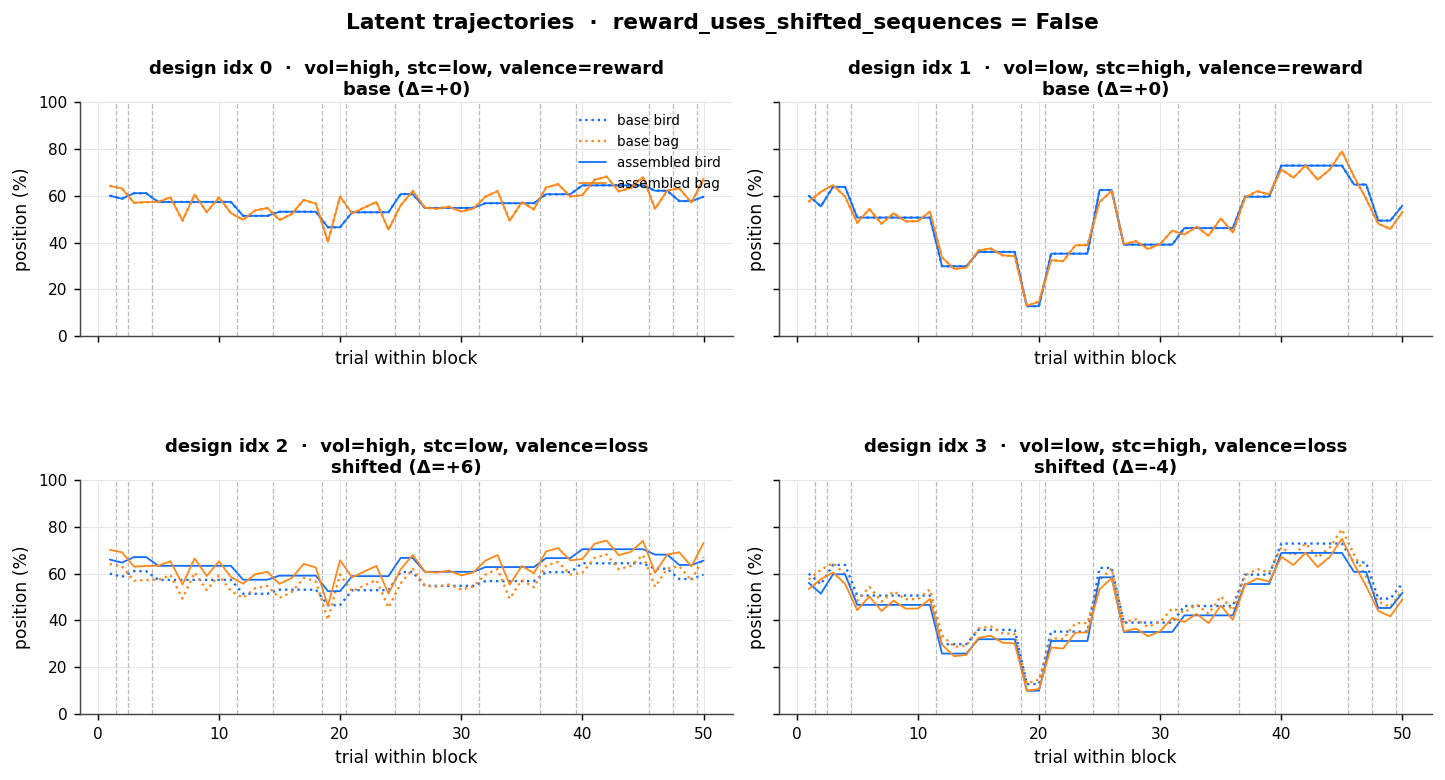

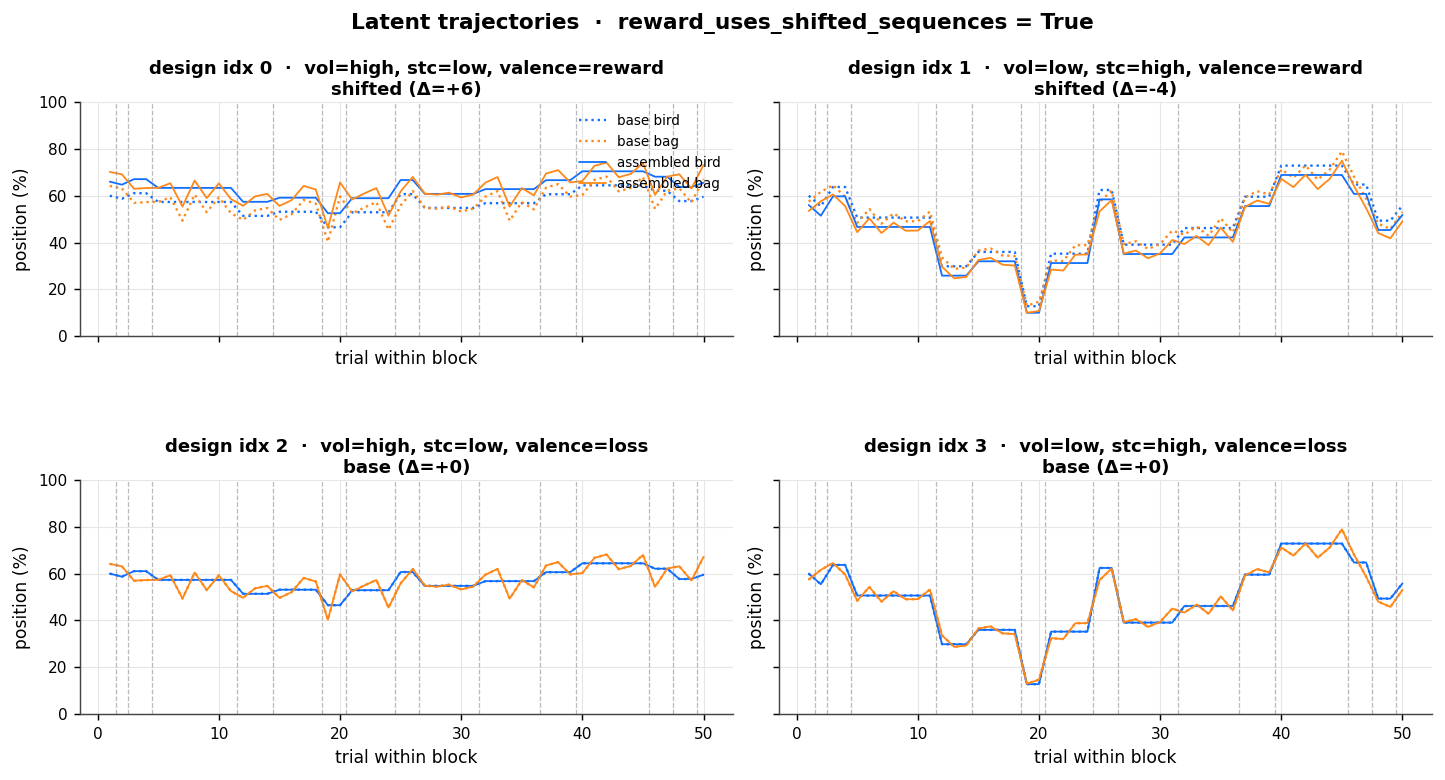

In [66]:
PALETTE_BIRD = "#106FFF"   # navy
PALETTE_BAG  = "#FF8818"   
PALETTE_CP   = "#8c8c8c"   


def plot_trajectories(reward_uses_shifted: bool):
    bird, bag = assemble_trajectories(reward_uses_shifted)
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.0), sharex=True, sharey=True)
    fig.set_constrained_layout_pads(h_pad=0.10, hspace=0.18)
    axes = axes.ravel()

    for idx in range(4):
        ax = axes[idx]
        x = np.arange(1, bird.shape[1] + 1)
        base_idx = 0 if idx in (0, 2) else 1

        ax.plot(x, main_bird[base_idx], lw=1.3, ls=":",  alpha=1, color=PALETTE_BIRD, label="base bird")
        ax.plot(x, main_bag[base_idx],  lw=1.3, ls=":",  alpha=1, color=PALETTE_BAG,  label="base bag")
        ax.plot(x, bird[idx], lw=1, color=PALETTE_BIRD, label="assembled bird")
        ax.plot(x, bag[idx],  lw=1, color=PALETTE_BAG,  label="assembled bag")

        for cp in infer_change_points_from_sequence(bird[idx]):
            ax.axvline(cp - 0.5, color=PALETTE_CP, lw=0.7, ls="--", alpha=0.6)

        v = "high" if _is_high_vol(idx) else "low"
        s = "high" if design["factors_stc"][idx] == 64 else "low"
        val = design["factors_valence"][idx]
        status, delta = _shifted_status(idx, reward_uses_shifted)
        ax.set_title(
            f"design idx {idx}  ·  vol={v}, stc={s}, valence={val}\n"
            f"{status} (Δ={delta:+d})",
            fontsize=10, pad=4,
        )
        ax.set_xlabel("trial within block")
        ax.set_ylabel("position (%)")
        ax.set_ylim(0, 100)
        if idx == 0:
            ax.legend(loc="upper right", ncol=1, fontsize=7.5)

    fig.suptitle(f"Latent trajectories  ·  reward_uses_shifted_sequences = {reward_uses_shifted}",
                 fontsize=12, fontweight="semibold")
    return fig


for flag in (False, True):
    fig = plot_trajectories(flag)
    fig.savefig(OUT_DIR / f"trajectories_reward_shifted_{str(flag).lower()}.png")
    plt.show()


## Memory-task structure

The 14 `PREDEFINED_PAIRS` are fixed 1-based within-block trial
indices. A subset (`SLIDER_PAIRS`) additionally probes the *middle*
item by slider; among slider pairs, some straddle a change point
(`BOUNDARY_MIDDLE_PAIRS`) and others do not (`NONBOUNDARY_MIDDLE_PAIRS`).


In [46]:
def pair_kind(pair: tuple) -> str:
    if pair in BOUNDARY_MID:  return "slider · boundary-mid"
    if pair in NONBOUND_MID:  return "slider · non-boundary-mid"
    if pair in SLIDER_PAIRS:  return "slider"
    return "order+distance only"


pair_table = pd.DataFrame({
    "pair_id":      range(1, len(PAIRS) + 1),
    "first_trial":  [p[0] for p in PAIRS],
    "second_trial": [p[1] for p in PAIRS],
    "middle_trial": [(p[0] + p[1]) // 2 for p in PAIRS],
    "gap":          [p[1] - p[0] for p in PAIRS],
    "kind":         [pair_kind(p) for p in PAIRS],
})

save_table_html(pair_table, "pair_table",
                caption="Memory-task pairs (1-based within-block trial indices)")
print(f"max trial index probed: {max(itertools.chain.from_iterable(PAIRS))}")
style_table(pair_table, caption="Memory-task pairs")


max trial index probed: 45


pair_id,first_trial,second_trial,middle_trial,gap,kind
1,2,4,3,2,slider · boundary-mid
2,6,9,7,3,order+distance only
3,7,10,8,3,order+distance only
4,11,13,12,2,slider · boundary-mid
5,16,18,17,2,slider · non-boundary-mid
6,17,20,18,3,order+distance only
7,22,24,23,2,slider · non-boundary-mid
8,23,26,24,3,order+distance only
9,28,31,29,3,order+distance only
10,30,33,31,3,order+distance only


### Pair coverage along the trial axis

Each row is one pair; the marker conventions are: dot = order-test
endpoints, × = slider middle item. Inferred change points (from the
parsed trajectories) are overlaid in the background.


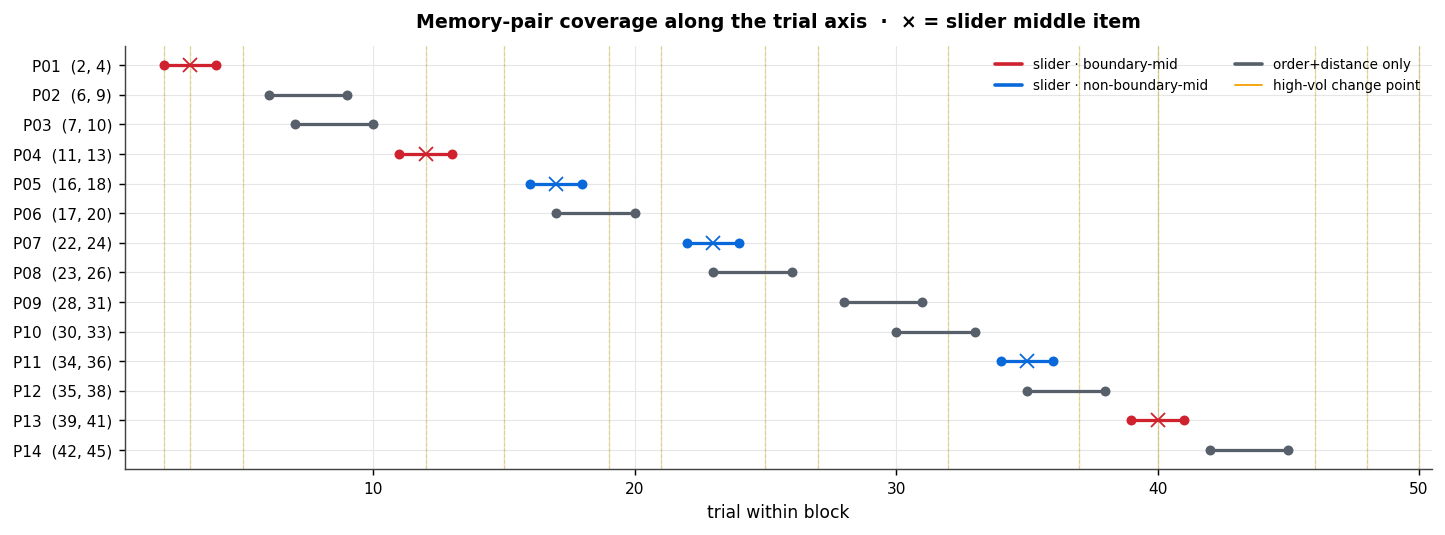

In [69]:
PAIR_COLORS = {
    "slider · boundary-mid":     "#cf222e",
    "slider · non-boundary-mid": "#0969da",
    "order+distance only":       "#57606a",
}

# pull change-points off the parsed (un-shifted) sequences for backdrop
_high_cps = infer_change_points_from_sequence(main_bird[0])
_low_cps  = infer_change_points_from_sequence(main_bird[1])

fig, ax = plt.subplots(figsize=(11, 4.0))

for cp in _high_cps:
    ax.axvline(cp, color="#f59f00", lw=0.8, alpha=0.30)
for cp in _low_cps:
    ax.axvline(cp, color="#2f9e44", lw=0.6, alpha=0.20, ls="--")

for i, p in enumerate(PAIRS, start=1):
    color = PAIR_COLORS[pair_kind(p)]
    ax.plot([p[0], p[1]], [i, i], "-", color=color, lw=1.8, zorder=3)
    ax.plot([p[0], p[1]], [i, i], "o", color=color, markersize=4.5, zorder=4)
    if p in SLIDER_PAIRS:
        ax.plot((p[0] + p[1]) // 2, i, "x", color=color, markersize=8, zorder=5)

ax.set_yticks(range(1, len(PAIRS) + 1))
ax.set_yticklabels([f"P{i:02d}  {p}" for i, p in enumerate(PAIRS, 1)])
ax.set_xlabel("trial within block")
ax.set_xlim(0.5, 50.5)
ax.invert_yaxis()
ax.set_title("Memory-pair coverage along the trial axis  ·  × = slider middle item",
             pad=10)

handles = [plt.Line2D([0], [0], color=c, lw=2, label=k) for k, c in PAIR_COLORS.items()]
handles += [
    plt.Line2D([0], [0], color="#f59f00", lw=1, label="high-vol change point"),
]
ax.legend(handles=handles, loc="upper right", fontsize=7.5, ncol=2)

fig.savefig(OUT_DIR / "pair_coverage.png")
plt.show()


## Emoji-to-trial mapping

The runtime code shuffles the emoji pool once per participant, then
walks it sequentially: trial *k* (zero-indexed globally) gets
`pool[k % len(pool)]`. The `randomized` permutation does **not**
affect emoji selection — only which trajectory plays in which
playback slot.

We use a deterministic seed below to materialise a single
representative participant's emoji sequence; everything downstream
(memory items, ribbons) is derived from this dataframe.


In [48]:
def simulate_emoji_assignment(seed: int = 42, n_trials_per_block: int = 50,
                              n_blocks: int = 4) -> pd.DataFrame:
    """One simulated participant's deterministic emoji assignment."""
    rng = np.random.default_rng(seed)
    pool = list(emojis); rng.shuffle(pool)
    rows = []
    k = 0
    for j in range(n_blocks):
        for i in range(n_trials_per_block):
            rows.append({"k": k, "block": j + 1, "trial": i + 1,
                         "stim_img": pool[k % len(pool)]})
            k += 1
    return pd.DataFrame(rows)


emoji_df = simulate_emoji_assignment(seed=42)
preview = pd.concat([
    emoji_df[emoji_df.block == j].iloc[[0, 1, 2, -3, -2, -1]] for j in range(1, 5)
])
style_table(preview.assign(stim_img=preview.stim_img),
            caption="First and last 3 trials of each block (deterministic seed=42)")


k,block,trial,stim_img
0,1,1,🚦
1,1,2,🧆
2,1,3,🪣
47,1,48,🧼
48,1,49,👒
49,1,50,🩰
50,2,1,🪻
51,2,2,🥞
52,2,3,🍿
97,2,48,🫙


### Memory items per block

For the same simulated participant, list the 14 pairs the memory test
will surface for each block. This is what `memory_task.js` looks up
via `block_trials[idx-1].stim_img` after filtering by `block` and
sorting by `trial`.


In [49]:
def memory_items_per_block(emoji_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for j in sorted(emoji_df["block"].unique()):
        bdf = emoji_df[emoji_df.block == j].set_index("trial")
        for i, p in enumerate(PAIRS, start=1):
            mid = (p[0] + p[1]) // 2
            rows.append({
                "block":        int(j),
                "pair_id":      i,
                "pair":         p,
                "kind":         pair_kind(p),
                "first_emoji":  bdf.loc[p[0], "stim_img"],
                "middle_emoji": bdf.loc[mid, "stim_img"] if p in SLIDER_PAIRS else "",
                "second_emoji": bdf.loc[p[1], "stim_img"],
            })
    return pd.DataFrame(rows)


mem_items = memory_items_per_block(emoji_df)
save_table_html(mem_items, "memory_items_per_block",
                caption="Memory items the test will display per block (seed=42)")
style_table(mem_items, caption="Memory items per block")


block,pair_id,pair,kind,first_emoji,middle_emoji,second_emoji
1,1,"(2, 4)",slider · boundary-mid,🧆,🪣,🪅
1,2,"(6, 9)",order+distance only,🤿,,📽️
1,3,"(7, 10)",order+distance only,🧄,,☎️
1,4,"(11, 13)",slider · boundary-mid,🫘,🖍️,🌺
1,5,"(16, 18)",slider · non-boundary-mid,🪕,🪮,👖
1,6,"(17, 20)",order+distance only,🪮,,🍧
1,7,"(22, 24)",slider · non-boundary-mid,🌻,🎹,🫖
1,8,"(23, 26)",order+distance only,🎹,,🍱
1,9,"(28, 31)",order+distance only,🎱,,🪶
1,10,"(30, 33)",order+distance only,🏉,,🪞


### Publication-style emoji ribbons

A standalone HTML rendering of the four 50-trial emoji ribbons with
pair-test items shaded yellow, slider middle items shaded blue, and
inferred bird-position boundaries marked by a red rule + red outline
on the first post-boundary item. Pair IDs (`P01`…`P14`) are printed
on each tested cell. Suitable for screenshotting or embedding as a
figure.

#### Helper — boundary inference

`infer_boundaries_from_positions` flags trial-to-trial latent shifts
that meet a magnitude threshold (either explicit or computed as a
quantile of nonzero shifts). Each boundary is reported as the trial
*before* the shift, the trial *after* (the first post-boundary item),
and the signed magnitude.


In [50]:
def infer_boundaries_from_positions(position_seq, threshold: float | None = None,
                                    quantile: float = 0.85):
    pos = np.asarray(position_seq, dtype=float)
    diffs = np.diff(pos)
    nonzero = np.abs(diffs[diffs != 0])
    if threshold is None:
        threshold = float(np.quantile(nonzero, quantile)) if nonzero.size else float("inf")
    boundaries = [
        {"after_trial": i + 1, "item_trial": i + 2,
         "delta": float(d), "abs_delta": float(abs(d))}
        for i, d in enumerate(diffs) if abs(d) >= threshold and abs(d) > 0
    ]
    return boundaries, threshold


def _build_pair_lookup(pairs: list[tuple]) -> dict[int, list[str]]:
    """trial → ['P01', 'P04', ...]"""
    lookup: dict[int, list[str]] = {}
    for i, (a, b) in enumerate(pairs, start=1):
        label = f"P{i:02d}"
        lookup.setdefault(a, []).append(label)
        lookup.setdefault(b, []).append(label)
    return lookup


def _format_boundary_list(boundaries: list[dict]) -> str:
    if not boundaries:
        return "none"
    return "; ".join(
        f"{b['after_trial']}|{b['item_trial']} "
        f"{'↑' if b['delta'] > 0 else '↓'}{abs(b['delta']):.1f}"
        for b in boundaries
    )


#### Helper — HTML ribbon builder

Builds a single self-contained HTML document with embedded CSS. The
function signature exposes only what callers care about (the emoji
dataframe, an optional bird-position array used for boundary
inference, threshold or quantile, and an output path). Renders inline
via `IPython.display.HTML`.


In [51]:
_RIBBON_CSS = '''
<style>
  .ribbon-doc {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
    color: #222; background: #fff; padding: 18px 8px;
  }
  .ribbon-doc h1 { font-size: 18px; font-weight: 750; margin: 0 0 8px 0; }
  .ribbon-doc h2 { font-size: 14px; font-weight: 700; margin: 22px 0 6px 0; }
  .ribbon-doc .figure-note,
  .ribbon-doc .caption    { font-size: 11.5px; color: #444; line-height: 1.45; max-width: 1350px; }
  .ribbon-doc .legend     { display: flex; flex-wrap: wrap; gap: 6px 14px; align-items: center;
                            font-size: 11.5px; color: #333; margin: 8px 0 14px 0; }
  .ribbon-doc .legend-item{ display: inline-flex; align-items: center; gap: 5px; white-space: nowrap; }
  .ribbon-doc .swatch     { display: inline-block; width: 16px; height: 12px; border-radius: 2px; }
  .ribbon-doc .swatch.tested         { background: #fff3a3; border: 1px solid #b58a00; }
  .ribbon-doc .swatch.slider         { background: #cfe8ff; border: 1px solid #2b6cb0; }
  .ribbon-doc .swatch.boundary-item  { background: #fff;    border: 2px solid #d62728; }
  .ribbon-doc .swatch.boundary-line  { width: 3px; height: 16px; background: #d62728; }
  .ribbon-doc .pair-legend { font-size: 11px; line-height: 1.45; max-width: 1400px;
                             font-family: ui-monospace, Menlo, Consolas, monospace; margin-bottom: 14px; }
  .ribbon-doc .ribbon-title { font-weight: 700; font-size: 12.5px; margin: 14px 0 4px 0; }
  .ribbon-doc table.ribbon  { border-collapse: collapse; table-layout: fixed; width: 100%;
                              max-width: 1500px; }
  .ribbon-doc table.ribbon td { width: 2%; height: 56px; border: 1px solid #d2d2d2;
                                font-size: 19px; text-align: center; vertical-align: middle;
                                position: relative; background: #fff; overflow: visible; }
  .ribbon-doc table.ribbon td.tested        { background: #fff3a3; border-color: #b58a00; }
  .ribbon-doc table.ribbon td.slider-mid    { background: #cfe8ff; border-color: #2b6cb0; }
  .ribbon-doc table.ribbon td.boundary-item { outline: 3px solid #d62728; outline-offset: -3px; }
  .ribbon-doc table.ribbon td.boundary-after::after {
      content: ""; position: absolute; top: -6px; right: -2px; height: 68px;
      border-right: 3px solid #d62728; z-index: 6; }
  .ribbon-doc .pair-label, .ribbon-doc .slider-label, .ribbon-doc .boundary-label {
      position: absolute; font-family: ui-monospace, Menlo, Consolas, monospace;
      font-size: 8px; line-height: 1.05; font-weight: 800;
      background: rgba(255,255,255,0.85); border-radius: 3px; padding: 1px 2px; }
  .ribbon-doc .pair-label    { top: 2px; left: 2px;   color: #5b4400; }
  .ribbon-doc .slider-label  { top: 2px; right: 2px;  color: #004b88; }
  .ribbon-doc .boundary-label{ bottom: 2px; left: 3px; color: #d62728; z-index: 7; }
  .ribbon-doc .trial-num     { position: absolute; bottom: 2px; right: 3px; font-size: 8px; color: #777; }
  .ribbon-doc table.boundary-table  { border-collapse: collapse; font-size: 11.5px;
                                      max-width: 1200px; margin-top: 6px; }
  .ribbon-doc table.boundary-table th, .ribbon-doc table.boundary-table td {
      border: 1px solid #d6d6d6; padding: 5px 8px; text-align: left; vertical-align: top; }
  .ribbon-doc table.boundary-table th { background: #f1f1f1; font-weight: 700; }
  .ribbon-doc code { background: #f4f4f4; border: 1px solid #ddd; padding: 1px 4px; border-radius: 3px; }
</style>
'''


def build_emoji_ribbons_html(emoji_df: pd.DataFrame,
                             bird_positions: np.ndarray | None = None,
                             title: str = "DroneTask emoji ribbons",
                             boundary_threshold: float | None = None,
                             boundary_quantile: float = 0.85,
                             pairs: list[tuple] = PAIRS,
                             slider_pairs: list[tuple] = SLIDER_PAIRS,
                             out_path: Path | None = None) -> str:
    tested = set(itertools.chain.from_iterable(pairs))
    sliders = set((a + b) // 2 for a, b in slider_pairs)
    pair_lookup = _build_pair_lookup(pairs)

    boundary_items: dict[int, set[int]] = {}
    boundary_after: dict[int, set[int]] = {}
    boundary_notes: list[dict] = []

    if bird_positions is not None:
        bird_positions = np.asarray(bird_positions, dtype=float)
        for block in sorted(emoji_df["block"].unique()):
            bnds, thr = infer_boundaries_from_positions(
                bird_positions[int(block) - 1],
                threshold=boundary_threshold, quantile=boundary_quantile)
            boundary_items[block] = {b["item_trial"] for b in bnds}
            boundary_after[block] = {b["after_trial"] for b in bnds}
            boundary_notes.append({"block": int(block), "threshold": thr,
                                   "boundaries": _format_boundary_list(bnds)})

    pair_legend = "; ".join(f"P{i:02d}: {a}↔{b}" for i, (a, b) in enumerate(pairs, 1))

    out = ['<!DOCTYPE html><html><head><meta charset="UTF-8">',
           f"<title>{html_lib.escape(title)}</title>", _RIBBON_CSS, "</head><body>",
           '<div class="ribbon-doc">',
           f"<h1>{html_lib.escape(title)}</h1>",
           '<div class="figure-note">'
           "Each row shows one block's 50-item sequence. Pair-test items, slider middle items, "
           "and inferred latent-position boundaries are annotated directly on the cells.</div>",
           '<div class="legend">',
           '<span class="legend-item"><span class="swatch tested"></span>pair-tested item</span>',
           '<span class="legend-item"><span class="swatch slider"></span>slider middle item</span>',
           '<span class="legend-item"><span class="swatch boundary-item"></span>first post-boundary item</span>',
           '<span class="legend-item"><span class="swatch boundary-line"></span>boundary between items</span>',
           '<span class="legend-item"><strong>Pxx</strong> pair ID</span>',
           '<span class="legend-item"><strong>B</strong> post-boundary marker</span>',
           "</div>",
           f'<div class="pair-legend"><strong>Pair IDs:</strong> {html_lib.escape(pair_legend)}</div>']

    for block in sorted(emoji_df["block"].unique()):
        bdf = emoji_df[emoji_df.block == block].sort_values("trial").set_index("trial")
        bi, ba = boundary_items.get(block, set()), boundary_after.get(block, set())
        out.append(f'<div class="ribbon-title">Block {block}</div><table class="ribbon"><tr>')
        for t in range(1, 51):
            classes = []
            if t in tested:  classes.append("tested")
            if t in sliders: classes.append("slider-mid")
            if t in bi:      classes.append("boundary-item")
            if t in ba:      classes.append("boundary-after")
            labels = pair_lookup.get(t, [])
            inner = "".join([
                f'<div class="pair-label">{"<br>".join(labels)}</div>' if labels else "",
                '<div class="slider-label">MID</div>' if t in sliders else "",
                '<div class="boundary-label">B</div>' if t in bi else "",
                f'<span style="font-size:20px">{html_lib.escape(str(bdf.loc[t, "stim_img"]))}</span>',
                f'<div class="trial-num">{t}</div>',
            ])
            out.append(f'<td class="{" ".join(classes)}">{inner}</td>')
        out.append("</tr></table>")

    if boundary_notes:
        out.extend([
            "<h2>Boundary summary</h2>",
            '<div class="caption">Boundaries are inferred from large trial-to-trial changes '
            'in the latent bird position. <code>18|19 ↓6.6</code> means a boundary between '
            'trials 18 and 19; trial 19 is the first post-boundary item; the bird moved down '
            'by 6.6 percentage points.</div>',
            '<table class="boundary-table"><tr><th>Block</th><th>Rule</th><th>Boundaries</th></tr>',
        ])
        for n in boundary_notes:
            rule = "no nonzero shifts" if np.isinf(n["threshold"]) else f"jump ≥ {n['threshold']:.2f} pts"
            out.append(f'<tr><td>Block {n["block"]}</td>'
                       f'<td>{html_lib.escape(rule)}</td>'
                       f'<td>{html_lib.escape(n["boundaries"])}</td></tr>')
        out.append("</table>")

    out.extend(["</div></body></html>"])
    text = "\n".join(out)

    if out_path is not None:
        Path(out_path).write_text(text, encoding="utf-8")
        print(f"Saved: {out_path}")
    return text


def render_emoji_ribbons(emoji_df, **kwargs):
    text = build_emoji_ribbons_html(emoji_df, **kwargs)
    display(HTML(text))
    return text


In [52]:
assembled_bird, _ = assemble_trajectories(reward_uses_shifted=False)
_ = render_emoji_ribbons(
    emoji_df,
    bird_positions=assembled_bird,
    boundary_threshold=8,
    out_path=OUT_DIR / "emoji_ribbons.html",
)


Saved: design_checks/emoji_ribbons.html


## Randomization analysis


### Metadata vs. trajectory simulator

`index.html` does `randomized = jsPsych.randomization.shuffle([0,1,2,3])`
and plays trajectory `main_*_position[randomized[j]]` in the j-th
playback slot. Recorded factor labels have two possible indexings:

- **`factors_*[j]`** (pre-fix) — labels reflect *playback position*.
  Because design indices have a `[high, low, high, low]` volatility
  pattern, this misaligns with the actual trajectory in 23 of 24
  permutations.
- **`factors_*[randomized[j]]`** (post-fix) — labels reflect the
  *trajectory played*. Aligned by construction.

Toggle `FACTORS_INDEXED_BY_RANDOMIZED` below to model whichever code
your data was collected under. The simulator reports both schemes
unconditionally so you can compare.


In [53]:
# True  → corrected: factors_*[randomized[j]]   (post-fix)
# False → buggy:     factors_*[j]               (pre-fix)
FACTORS_INDEXED_BY_RANDOMIZED = False


def simulate_run(randomized: list[int] | None = None,
                 reward_uses_shifted: bool = False,
                 factors_indexed_by_randomized: bool = FACTORS_INDEXED_BY_RANDOMIZED) -> pd.DataFrame:
    if randomized is None:
        randomized = list(np.random.permutation(4))
    rows = []
    for j, design_idx in enumerate(randomized):
        rec_idx = design_idx if factors_indexed_by_randomized else j
        rec_vol, rec_stc, rec_val = (design["factors_vol"][rec_idx],
                                     design["factors_stc"][rec_idx],
                                     design["factors_valence"][rec_idx])
        true_vol, true_stc, true_val = (design["factors_vol"][design_idx],
                                        design["factors_stc"][design_idx],
                                        design["factors_valence"][design_idx])
        rows.append({
            "playback_j":         j,
            "recorded_block":     j + 1,
            "design_idx_played":  design_idx,
            "recorded_vol":       rec_vol,  "actual_vol":  true_vol,  "vol_match":  rec_vol == true_vol,
            "recorded_stc":       rec_stc,  "actual_stc":  true_stc,  "stc_match":  rec_stc == true_stc,
            "recorded_valence":   rec_val,  "actual_valence": true_val, "valence_match": rec_val == true_val,
            "k_range":            f"[{j*50}…{j*50+49}]",
        })
    return pd.DataFrame(rows)


def _summarise(flag: bool) -> dict:
    counts = [0, 0, 0, 0]   # vol-only, stc-only, val-only, full
    for perm in itertools.permutations(range(4)):
        df = simulate_run(list(perm), factors_indexed_by_randomized=flag)
        counts[0] += int(df.vol_match.sum() == 4)
        counts[1] += int(df.stc_match.sum() == 4)
        counts[2] += int(df.valence_match.sum() == 4)
        counts[3] += int(df.vol_match.sum() + df.stc_match.sum() + df.valence_match.sum() == 12)
    return dict(zip(("vol", "stc", "val", "full"), counts))


comparison = pd.DataFrame([
    {"scheme": "post-fix (factors[randomized[j]])", **_summarise(True)},
    {"scheme": "pre-fix (factors[j])",              **_summarise(False)},
])
comparison.columns = ["scheme",
                      "vol all-4 (/24)", "stc all-4 (/24)",
                      "val all-4 (/24)", "all factors all blocks (/24)"]

print(f"Currently modelling FACTORS_INDEXED_BY_RANDOMIZED = {FACTORS_INDEXED_BY_RANDOMIZED}")
save_table_html(comparison, "permutation_summary",
                caption="How often each indexing scheme aligns recorded factors with the trajectory played")
style_table(comparison, caption="Recorded-vs-played factor alignment, across all 24 permutations")


Currently modelling FACTORS_INDEXED_BY_RANDOMIZED = False


scheme,vol all-4 (/24),stc all-4 (/24),val all-4 (/24),all factors all blocks (/24)
post-fix (factors[randomized[j]]),24,24,24,24
pre-fix (factors[j]),4,4,4,1


In [54]:
example = simulate_run([2, 0, 3, 1])
save_table_html(example, "simulate_run_example",
                caption=f"Single-participant simulation, randomized=[2,0,3,1], "
                        f"FACTORS_INDEXED_BY_RANDOMIZED={FACTORS_INDEXED_BY_RANDOMIZED}")
style_table(example, caption=f"randomized=[2,0,3,1] under current scheme")


playback_j,recorded_block,design_idx_played,recorded_vol,actual_vol,vol_match,recorded_stc,actual_stc,stc_match,recorded_valence,actual_valence,valence_match,k_range
0,1,2,49,49,True,16,16,True,reward,loss,False,[0…49]
1,2,0,4,49,False,64,16,False,reward,reward,True,[50…99]
2,3,3,49,4,False,16,64,False,loss,loss,True,[100…149]
3,4,1,4,4,True,64,64,True,loss,reward,False,[150…199]


### Static consistency report

A pass/fail audit of the parsed design. The metadata-fix detection
inspects `index.html` for the corrected indexing pattern and adapts
its verdict accordingly.


In [55]:
def report() -> pd.DataFrame:
    checks: list[dict] = []
    def add(label, ok, detail=""):
        checks.append({"check": label, "pass": "✓" if ok else "✗", "detail": detail})

    n_trials, n_designs = main_bird.shape[1], main_bird.shape[0]
    add("main_bird_position has 4 design rows", n_designs == 4, f"got {n_designs}")
    add("main_bag_position has 4 design rows",  main_bag.shape[0] == 4, f"got {main_bag.shape[0]}")
    add("bird and bag have same shape",         main_bird.shape == main_bag.shape,
        f"{main_bird.shape} vs {main_bag.shape}")
    add("trials per block == 50",               n_trials == 50, f"got {n_trials}")

    flens = {len(design["factors_vol"]), len(design["factors_stc"]), len(design["factors_valence"])}
    add("factor arrays all length 4", flens == {4}, f"lengths={flens}")

    add("emoji pool ≥ 200", len(emojis) >= 200, f"got {len(emojis)}")
    add("emoji pool unique", len(set(emojis)) == len(emojis),
        f"{len(emojis) - len(set(emojis))} duplicate(s)")

    max_pair = max(itertools.chain.from_iterable(PAIRS))
    add("max pair index ≤ trials/block", max_pair <= n_trials, f"max={max_pair}, trials={n_trials}")

    add("every SLIDER_PAIR is in PREDEFINED_PAIRS",
        all(p in PAIRS for p in SLIDER_PAIRS))
    add("every BOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS",
        all(p in SLIDER_PAIRS for p in BOUNDARY_MID))
    add("every NONBOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS",
        all(p in SLIDER_PAIRS for p in NONBOUND_MID))
    union = set(BOUNDARY_MID) | set(NONBOUND_MID)
    add("BOUNDARY_MID ∪ NONBOUND_MID size ≤ SLIDER_PAIRS size",
        len(union) <= len(SLIDER_PAIRS), f"{len(union)} vs {len(SLIDER_PAIRS)}")

    # Detect whether index.html applies the metadata fix
    html_src = sources["index.html"]
    has_design_idx = re.search(r"var\s+design_idx\s*=", html_src) is not None
    has_fix_lookup = re.search(r"factors_vol\[\s*(?:design_idx|randomized\[\s*j\s*\])\s*\]", html_src) is not None
    has_buggy_lookup = re.search(r"factors_vol\[\s*j\s*\]", html_src) is not None
    fix_applied = has_fix_lookup and not has_buggy_lookup
    add("metadata fix applied in index.html (factors_vol[design_idx|randomized[j]])",
        fix_applied,
        f"design_idx var: {has_design_idx}; fixed lookup: {has_fix_lookup}; "
        f"buggy lookup still present: {has_buggy_lookup}")

    return pd.DataFrame(checks)


_report_df = report()
save_table_html(_report_df, "consistency_report",
                caption="Static consistency report",
                pass_col="pass")
style_table(_report_df, caption="Static consistency report", pass_col="pass")


check,pass,detail
main_bird_position has 4 design rows,✓,got 4
main_bag_position has 4 design rows,✓,got 4
bird and bag have same shape,✓,"(4, 50) vs (4, 50)"
trials per block == 50,✓,got 50
factor arrays all length 4,✓,lengths={4}
emoji pool ≥ 200,✓,got 220
emoji pool unique,✓,0 duplicate(s)
max pair index ≤ trials/block,✓,"max=45, trials=50"
every SLIDER_PAIR is in PREDEFINED_PAIRS,✓,
every BOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS,✓,


## Repository sanity checks

A small set of regex probes against `index.html` and `memory_task.js`
to confirm the timeline structure hasn't drifted (timeline-data field,
loop wrapper, memory-test filter, main-path constants).


In [56]:
def _all_int_assignments(name: str, src: str) -> list[int]:
    return [int(m.group(1))
            for m in re.finditer(rf"(?:^|\W)(?:var\s+)?{name}\s*=\s*(\d+)\s*;", src, flags=re.M)]


_html = sources["index.html"]
_mem  = sources["memory_task.js"]

print("All assignments seen in index.html:")
for n in ("num_birds", "num_trials", "stayed_threshold"):
    print(f"  {n:18s} {_all_int_assignments(n, _html)}")

mp = re.search(r"practice_no\s*==\s*0[^{]*\{(.*?)\n\s*\}", _html, flags=re.S)
print("\nMain-path (practice_no==0) constants:")
if mp:
    for n in ("num_birds", "num_trials", "missed_threshold", "warning_threshold"):
        m = re.search(rf"{n}\s*=\s*(\d+)", mp.group(1))
        if m:
            print(f"  {n:20s} = {m.group(1)}")

# Timeline-data check tolerates inline comments now
data_blocks = re.findall(r"data:\s*\{([^}]+)\}", _html, flags=re.S)
trial_def_present = any(all(kw in db for kw in ("block:", "trial:", "stim_img"))
                        for db in data_blocks)

probes = pd.DataFrame([
    {"probe": "main trial defines data:{block, trial, stim_img}",
     "present": trial_def_present},
    {"probe": "trial wrapper has loop_function on .missing",
     "present": bool(re.search(r"loop_function:\s*function\s*\(\s*data\s*\)\s*\{\s*return\s+data\.values\(\)\[0\]\.missing", _html))},
    {"probe": "buildBirdMemoryTrials calls create_memory_timeline(b+1)",
     "present": bool(re.search(r"create_memory_timeline\s*\(\s*b\s*\+\s*1\s*\)", _html))},
    {"probe": "memory_task.js filters by {trial_type:'trial', block}",
     "present": bool(re.search(r"jsPsych\.data\.get\(\)[\s\.]*\.filter\(\{\s*trial_type:\s*['\"]trial['\"]\s*,\s*block:\s*block\s*\}\)", _mem, flags=re.S))},
])
probes["pass"] = probes["present"].map(lambda v: "✓" if v else "✗")
probes = probes[["probe", "pass"]]
save_table_html(probes, "structure_probes",
                caption="Timeline structure probes against the source files",
                pass_col="pass")
style_table(probes, caption="Timeline structure probes", pass_col="pass")


All assignments seen in index.html:
  num_birds          [1, 4]
  num_trials         [10, 1, 3, 3, 50]
  stayed_threshold   [4]

Main-path (practice_no==0) constants:
  num_birds            = 4
  num_trials           = 50
  missed_threshold     = 20
  warning_threshold    = 16


probe,pass
"main trial defines data:{block, trial, stim_img}",✓
trial wrapper has loop_function on .missing,✓
buildBirdMemoryTrials calls create_memory_timeline(b+1),✓
"memory_task.js filters by {trial_type:'trial', block}",✓


## Conclusion

**Memory-item display.** Static analysis of the chain (emoji selection
→ `data:{block,trial,stim_img}` merge → `memory_task.js`
filter/sort/lookup) is internally consistent. Each block records
`stim_img` for its 50 trials, and the memory plugin's filter on
`{trial_type:'trial', block:blockNum}` returns exactly that set sorted
by `trial`. There is no static path for an emoji from another block to
appear in the test. Plausible runtime causes for any reported mismatch
are listed in the previous chat thread and resolvable with a single
`console.log` in `memory_task.js`.

**Metadata fix (vol/stc/valence).** The `randomized` shuffle is real
counter-balancing, but `factors_*` were originally indexed by playback
position `j` rather than by `randomized[j]`. The *Static consistency
report* auto-detects whether the fix is in place; flip
`FACTORS_INDEXED_BY_RANDOMIZED` to `True` after applying the fix and
re-running data collection. **Only `index.html` needs editing for
this fix** — the JS plugins are pure read-through consumers of these
fields. For data already collected under the buggy code, the
`randomized` field is recorded per row, so the correct factors can be
recovered post-hoc by remapping `factors_*[randomized]`.
